# **Dataset Importing**

In [119]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\mrayy\.cache\kagglehub\datasets\mirichoi0218\insurance\versions\1


In [120]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


files = os.listdir(path)
print("Files in dataset:", files)


df = pd.read_csv(os.path.join(path, "insurance.csv"))

Files in dataset: ['insurance.csv']


In [121]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [122]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [123]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# **Visualization**

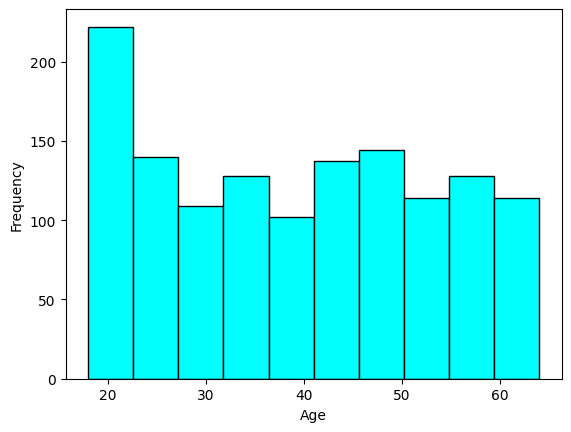

In [124]:
plt.hist(df["age"], color="aqua",  edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [125]:
sk_Age = df["age"].skew()
print(f"Skewness is: {sk_Age:.5f}")

Skewness is: 0.05567


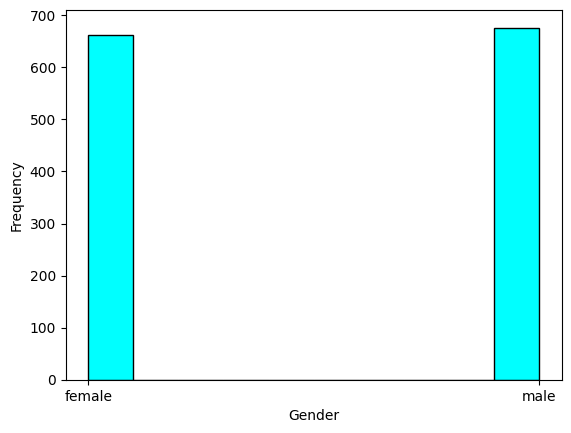

In [126]:
plt.hist(df["sex"], color="aqua",  edgecolor="black")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()

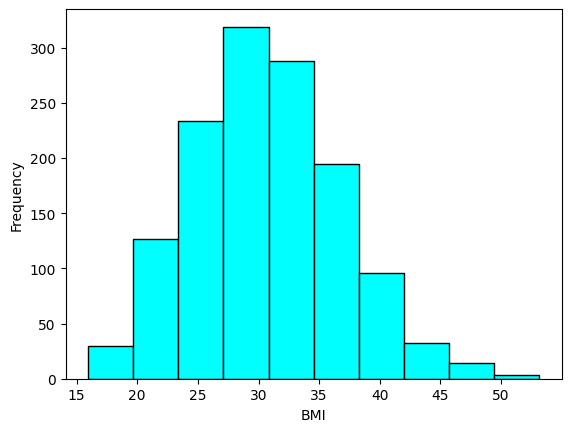

In [127]:
plt.hist(df["bmi"], color="aqua",  edgecolor="black")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

In [128]:
sk_BMI = df["bmi"].skew()
print(f"Skewness is: {sk_BMI:.5f}")

Skewness is: 0.28405


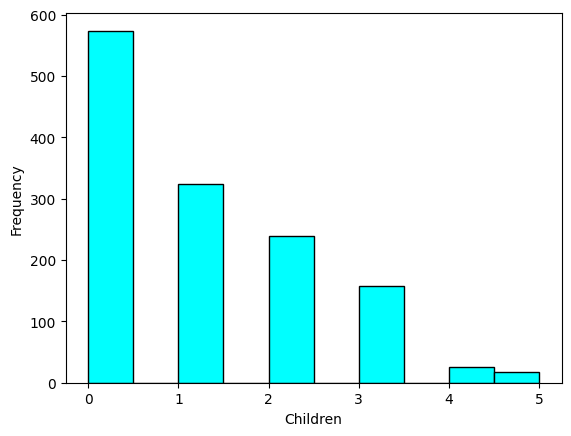

In [129]:
plt.hist(df["children"], color="aqua",  edgecolor="black")
plt.xlabel("Children")
plt.ylabel("Frequency")
plt.show()

In [130]:
sk_Children = df["children"].skew()
print(f"Skewness is: {sk_Children:.5f}")

Skewness is: 0.93838


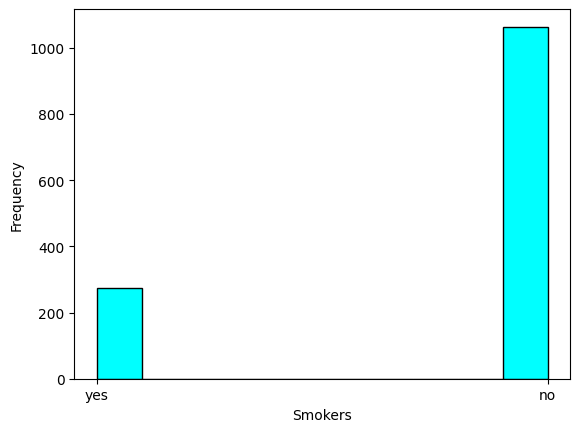

In [131]:
plt.hist(df["smoker"], color="aqua",  edgecolor="black")
plt.xlabel("Smokers")
plt.ylabel("Frequency")
plt.show()

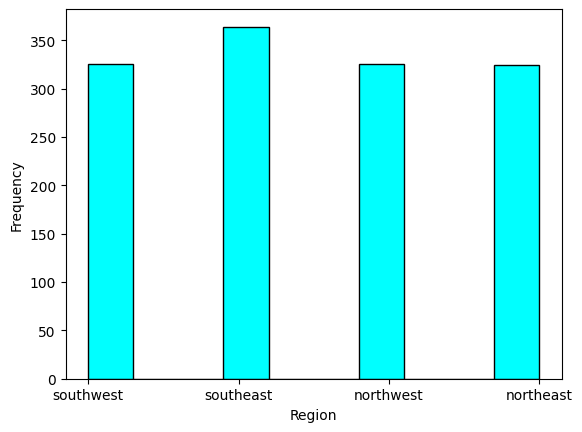

In [132]:
plt.hist(df["region"], color="aqua",  edgecolor="black")
plt.xlabel("Region")
plt.ylabel("Frequency")
plt.show()

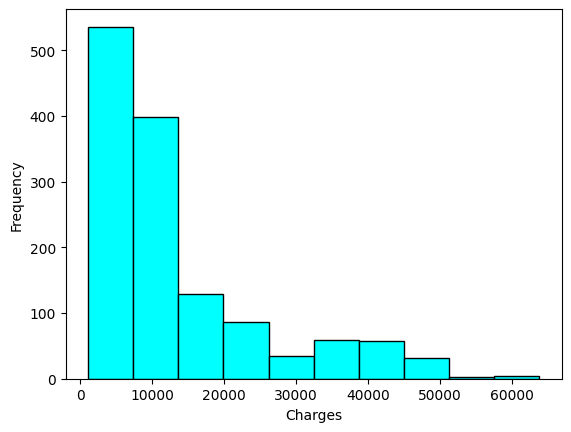

In [133]:
plt.hist(df["charges"], color="aqua",  edgecolor="black")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [134]:
sk_Charges = df["charges"].skew()
print(f"Skewness is: {sk_Charges:.5f}")

Skewness is: 1.51588


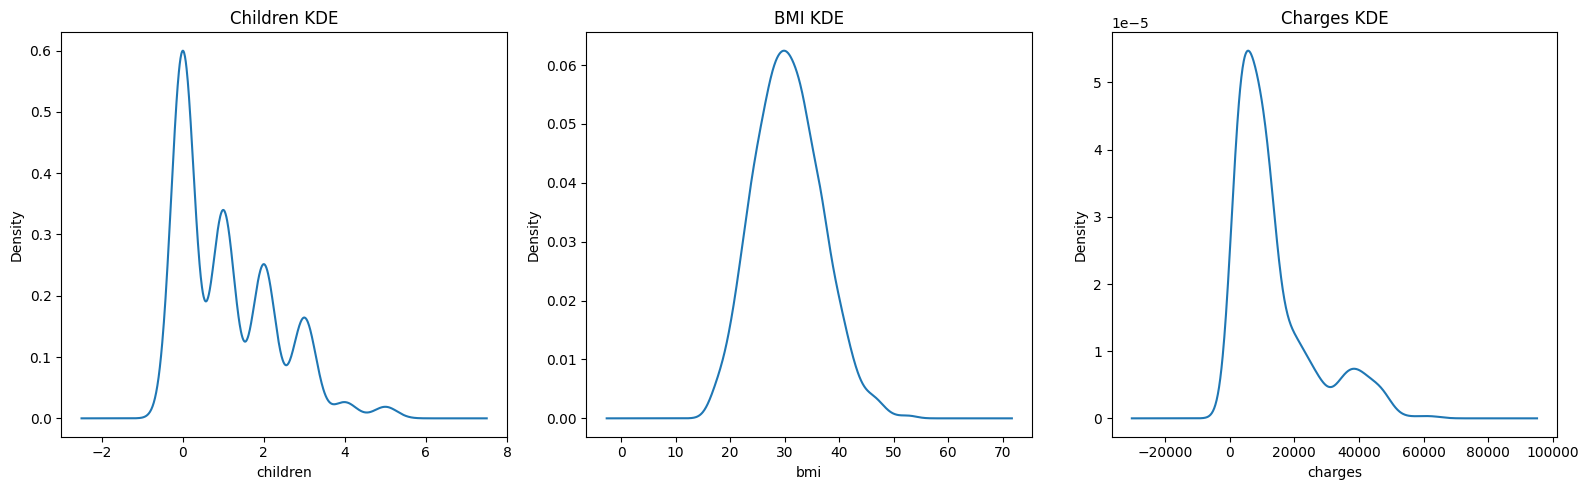

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df["children"].plot.kde(ax=axes[0], title="Children KDE")
df["bmi"].plot.kde(ax=axes[1], title="BMI KDE")
df["charges"].plot.kde(ax=axes[2], title="Charges KDE")

axes[0].set_xlabel("children")
axes[1].set_xlabel("bmi")
axes[2].set_xlabel("charges")

plt.tight_layout()
plt.show()

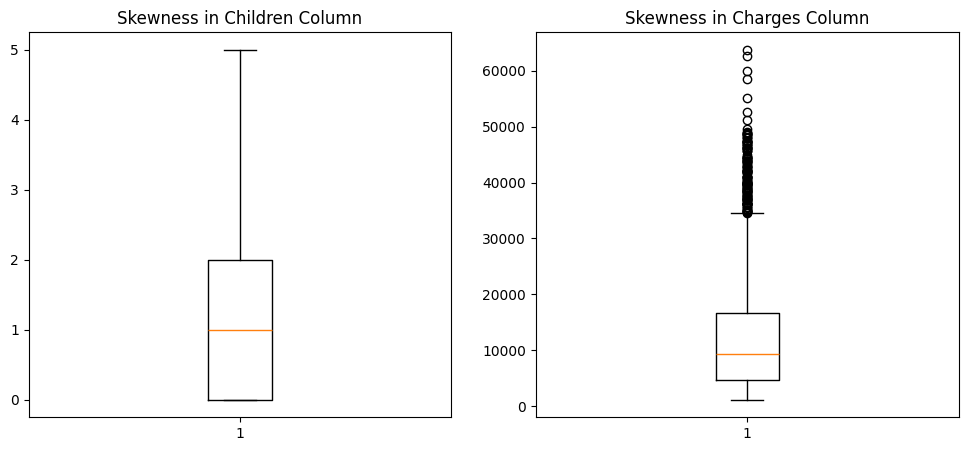

In [136]:
fig, axes  = plt.subplots(1,2, figsize=(12,5))

axes[0].boxplot(df["children"])
axes[0].set_title("Skewness in Children Column")


axes[1].boxplot(df["charges"])
axes[1].set_title("Skewness in Charges Column")

plt.show()

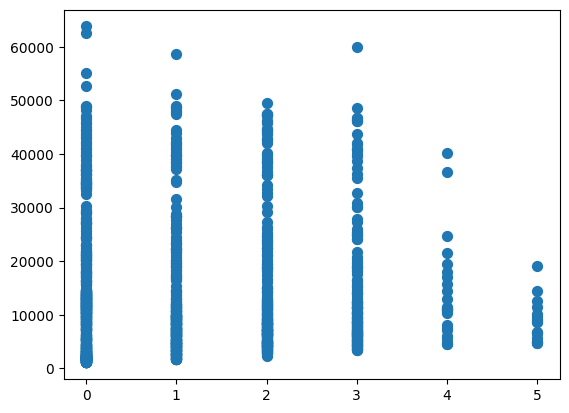

In [137]:
plt.scatter(df["children"],df["charges"] ,s=50, colorizer="red")

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [139]:
# Encode categorical features
model_df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


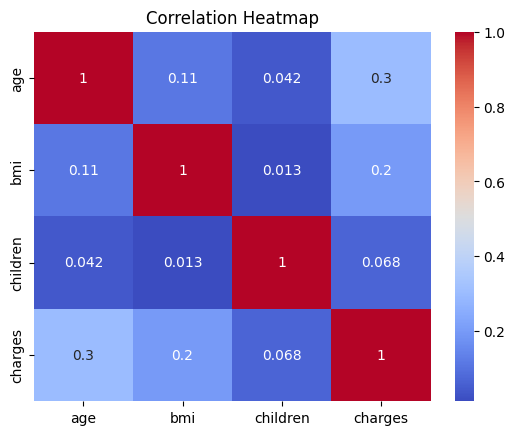

In [140]:
correlation_matrix = model_df[["age","bmi","children","charges"]].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [141]:
# vertical split
X = model_df.drop("charges", axis=1)
y = model_df["charges"]

<Axes: ylabel='Density'>

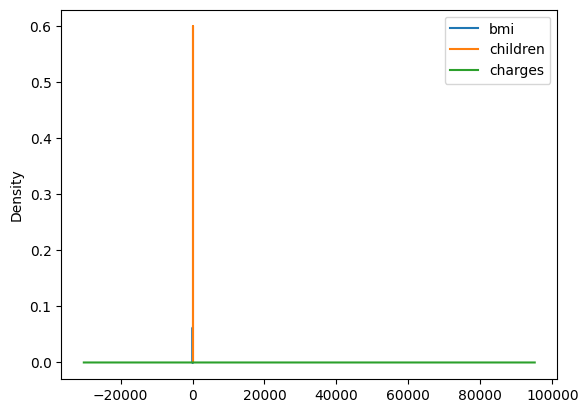

In [142]:
model_df[["bmi", "children", "charges"]].plot.kde()

In [143]:
from sklearn.preprocessing import StandardScaler,RobustScaler

scaler = RobustScaler()
scaled_data = scaler.fit_transform(model_df[["bmi", "children", "charges"]])
scaled_df = pd.DataFrame(scaled_data, columns=["bmi", "children", "charges"])


<Axes: ylabel='Density'>

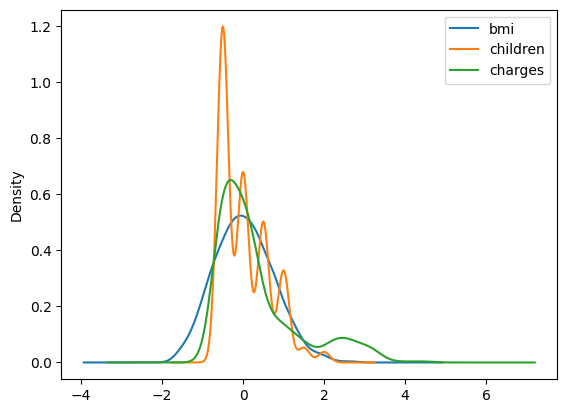

In [144]:
scaled_df[["bmi", "children", "charges"]].plot.kde()

# **Model Training**

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler0 = StandardScaler()
X_train_scaled = scaler0.fit_transform(X_train)
X_test_scaled = scaler0.transform(X_test)

In [146]:
# Regression modeling with Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)


In [147]:
lr.coef_

array([ 3.61497541e+03,  2.03622812e+03,  5.16890247e+02, -9.29310107e+00,
        9.55848141e+03, -1.58140981e+02, -2.90157047e+02, -3.49110678e+02])

In [148]:
model_df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# **Deature Importance**

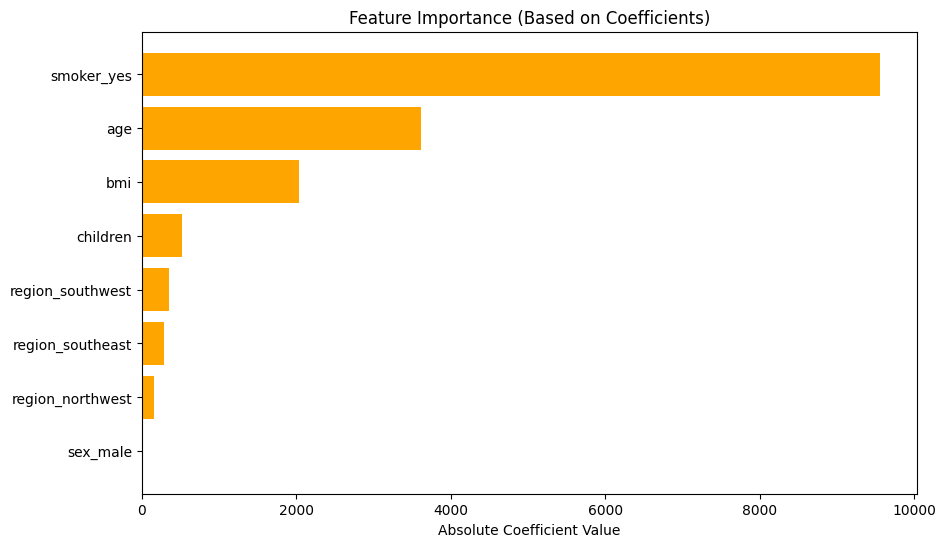

In [149]:
# Feature Importance

# 1. Coefficients nikalen (Absolute values lein taakay +ive/-ive dono ka asar dikhe)
importances = np.abs(lr.coef_) 
features = X.columns # Ya aapki feature list

# 2. Sorting 
indices = np.argsort(importances)

# 3. Ploting
plt.figure(figsize=(10, 6))
plt.title('Feature Importance (Based on Coefficients)')
plt.barh(range(len(indices)), importances[indices], color='orange', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Absolute Coefficient Value')
plt.show()


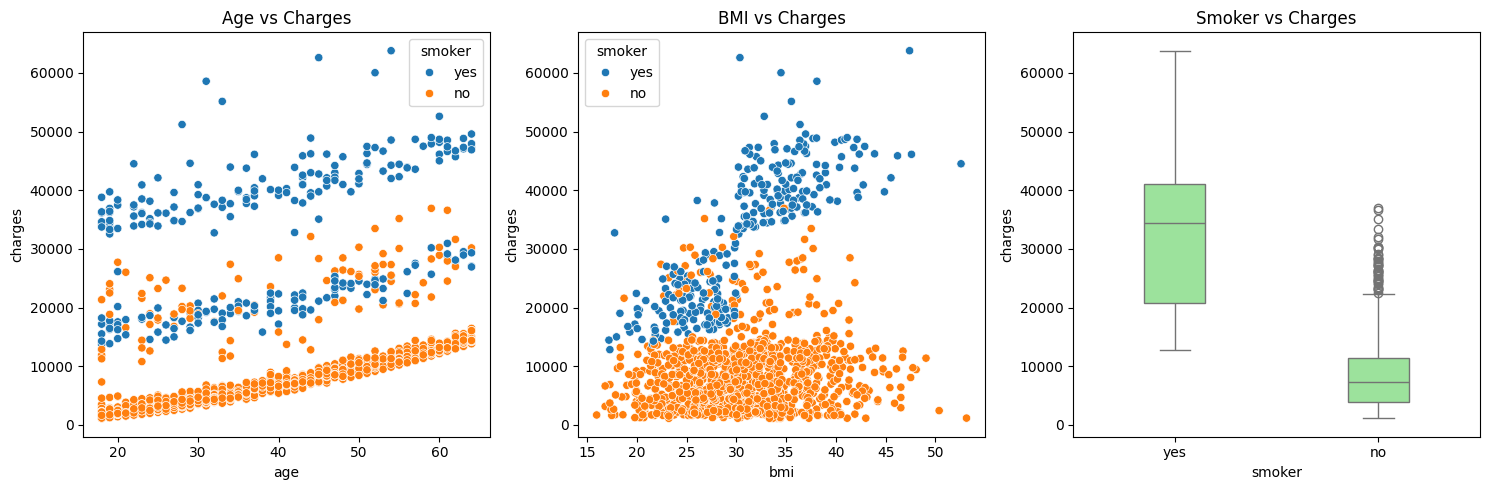

In [159]:
# Visualizations: Age, BMI, Smoker effect on charges
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(x="age", y="charges", data=df, hue="smoker", ax=axes[0])
axes[0].set_title("Age vs Charges")

sns.scatterplot(x="bmi", y="charges", data=df, hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs Charges")

sns.boxplot(x="smoker", y="charges", data=df, ax=axes[2], width=0.3, color="lightgreen")
axes[2].set_title("Smoker vs Charges")

plt.tight_layout()
plt.show()

# **Metrices Calculation**

MAE: 4181.19
RMSE: 5796.28
R2: 0.7836
Classification report (high-cost=1, low-cost=0):
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       146
           1       0.77      0.92      0.84       122

    accuracy                           0.84       268
   macro avg       0.85      0.85      0.84       268
weighted avg       0.85      0.84      0.84       268

Confusion matrix:
[[113  33]
 [ 10 112]]


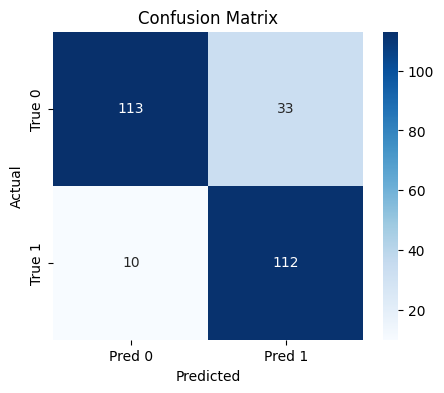

In [172]:
# Regression task: don’t use accuracy_score on continuous targets.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,classification_report,confusion_matrix

y_pred = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.4f}")


# Classification-style evaluation via binarized target (high cost vs low cost)
median_charge = df['charges'].median()
y_test_class = (y_test > median_charge).astype(int)
y_pred_class = (y_pred > median_charge).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification report (high-cost=1, low-cost=0):")
print(classification_report(y_test_class, y_pred_class))

cm = confusion_matrix(y_test_class, y_pred_class)
print("Confusion matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()